# LNL on GTSRB — Nhóm X (plug-and-play)

Đây là notebook gốc `Instructions.ipynb`, chỉ đổi: (1) `git clone`+`cd` trỏ về repo nhóm
(`bnqtoan/LNL-GTSRB-NhomX`, chứa **`LNL.py` cải tiến**); (2) train **25 epoch** thay vì 5 và dùng
**cosine LR decay** (StepLR gốc không bao giờ kích hoạt trong <30 epoch). Vẫn SGD lr=0.007.

Mọi cải tiến mô hình nằm trong `LNL.py` và tự kích hoạt khi train: chuẩn hoá đầu vào trong model,
augmentation nhẹ (tự tắt lúc test), LayerScale, qkv_bias, gộp đặc trưng CLS + mean-pool.

**Cách chạy:** Runtime → Change runtime type → **GPU (T4)** → **Run all** (~2h trên T4).
Số cần báo cáo là **`Standard accuracy`** ở cell Test.

In [1]:
!nvidia-smi

Tue Jun 23 02:47:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/bnqtoan/LNL-GTSRB-NhomX.git

Cloning into 'LNL-GTSRB-NhomX'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 53 (delta 24), reused 44 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 1.43 MiB | 10.04 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [3]:
cd /content/LNL-GTSRB-NhomX

/content/LNL-GTSRB-NhomX


In [4]:
pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 18.2 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: re

In [5]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary

In [6]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [7]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  11.4M      0  0:00:23  0:00:23 --:--:-- 13.0M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  8267k      0  0:00:10  0:00:10 --:--:-- 9703k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0  70062      0  0:00:01  0:00:01 --:--:-- 70056


In [8]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [9]:
import shutil

In [10]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]


  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [11]:
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7)
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)

#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]


In [12]:
batch_size = 15

trainset = torchvision.datasets.ImageFolder(root='./data/GTSRB/Final_Training/Images',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

In [13]:
batch = next(iter(train_loader))
train_data = batch[0]

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

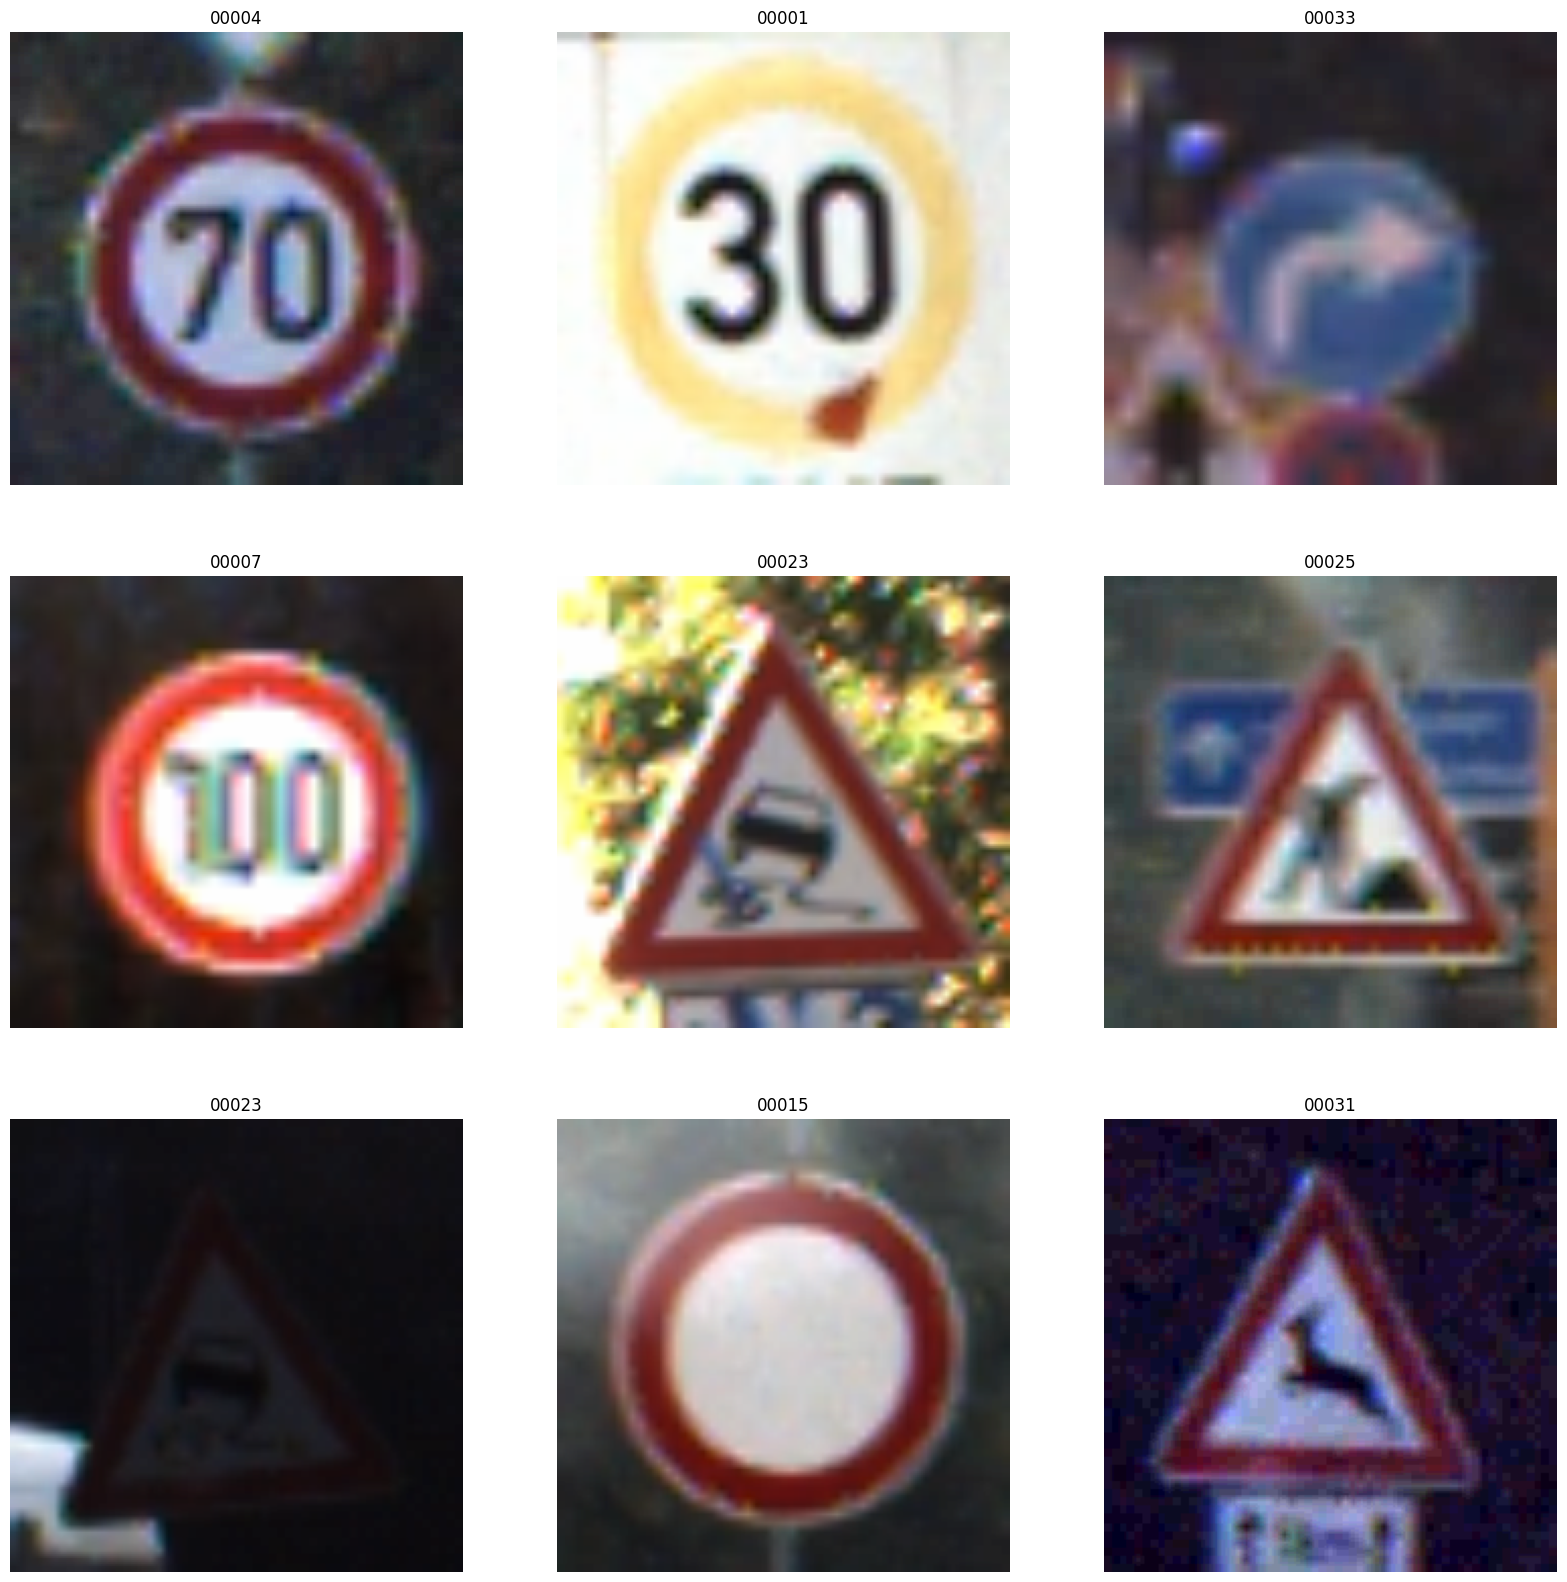

In [15]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [16]:
pip install timm

In [17]:
pip install einops

In [18]:
from LNL import LNL_Ti as small

/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/LNL-GTSRB-NhomX/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered conf

In [19]:
model = small(pretrained=False)

In [20]:
model.head

Linear(in_features=192, out_features=1000, bias=True)

In [21]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [22]:
model = model.cuda()

## Train Locality-iN-Locality

In [23]:
num_epochs = 25   # was 5: 5-epoch SGD underfits a 12-layer TNT (~97.7%); 25 ep lets it converge

In [24]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
# cosine LR decay over the run (the original StepLR(step=30) never fires in <30 epochs
# so LR stayed constant and plateaued just short of target). Same SGD, just decayed.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [25]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.cuda()
        Y = batch_labels.cuda()

        pre = model(X)
        cost = loss(pre, Y)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))
    scheduler.step()   # decay LR once per epoch (cosine)

Epoch [1/25], lter [200/2613], Loss: 3.024917
Epoch [1/25], lter [400/2613], Loss: 2.050923
Epoch [1/25], lter [600/2613], Loss: 1.895740
Epoch [1/25], lter [800/2613], Loss: 1.552371
Epoch [1/25], lter [1000/2613], Loss: 2.371984
Epoch [1/25], lter [1200/2613], Loss: 1.020878
Epoch [1/25], lter [1400/2613], Loss: 0.606485
Epoch [1/25], lter [1600/2613], Loss: 0.732734
Epoch [1/25], lter [1800/2613], Loss: 0.184236
Epoch [1/25], lter [2000/2613], Loss: 0.101816
Epoch [1/25], lter [2200/2613], Loss: 0.175696
Epoch [1/25], lter [2400/2613], Loss: 0.144377
Epoch [1/25], lter [2600/2613], Loss: 0.034501
Epoch [2/25], lter [200/2613], Loss: 0.066078
Epoch [2/25], lter [400/2613], Loss: 0.011355
Epoch [2/25], lter [600/2613], Loss: 0.103790
Epoch [2/25], lter [800/2613], Loss: 0.007305
Epoch [2/25], lter [1000/2613], Loss: 0.063278
Epoch [2/25], lter [1200/2613], Loss: 0.038617
Epoch [2/25], lter [1400/2613], Loss: 0.034140
Epoch [2/25], lter [1600/2613], Loss: 0.001866
Epoch [2/25], lter [1

## Test

In [26]:
model.eval()
correct = 0
total = 0

for images, labels in test_loader:

    images = images.cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 98.58 %


## FGSM attack

In [27]:
model.eval()

correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 67.02 %


## PGD attack

In [28]:
model.eval()

correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 48.13 %


## train LNL-MoEx

In [29]:
from LNL_MoEx import LNL_MoEx_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

/content/LNL-GTSRB-NhomX/models/tnt_moex.py:312: UserWarning: Overwriting tnt_t_patch16_224 in registry with models.tnt_moex.tnt_t_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/LNL-GTSRB-NhomX/models/tnt_moex.py:323: UserWarning: Overwriting tnt_s_patch16_224 in registry with models.tnt_moex.tnt_s_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/LNL-GTSRB-NhomX/models/tnt_moex.py:334: UserWarning: Overwriting tnt_b_patch16_224 in registry with models.tnt_moex.tnt_b_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model


In [30]:
model = model.cuda()

In [31]:
import time
# time.clock_gettime()

In [32]:
num_epochs = 5
moex_lam = .9
moex_prob = .7

In [33]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [ ]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (input, target) in enumerate(train_loader):
        input = input.cuda()
        target = target.cuda()

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]
            output = model(input, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss(output, target_a) * lam + loss(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model(input)
            # if args.prof >= 0: torch.cuda.nvtx.range_pop()
            cost = loss(output, target)

        # compute gradient and do SGD step

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

Epoch [1/5], lter [200/2613], Loss: 3.373123
Epoch [1/5], lter [400/2613], Loss: 3.348600
Epoch [1/5], lter [600/2613], Loss: 1.999333
Epoch [1/5], lter [800/2613], Loss: 2.224888
Epoch [1/5], lter [1000/2613], Loss: 1.025170
Epoch [1/5], lter [1200/2613], Loss: 1.623568
Epoch [1/5], lter [1400/2613], Loss: 1.222697
Epoch [1/5], lter [1600/2613], Loss: 0.201323
Epoch [1/5], lter [1800/2613], Loss: 0.387460
Epoch [1/5], lter [2000/2613], Loss: 0.655491
Epoch [1/5], lter [2200/2613], Loss: 0.116190
Epoch [1/5], lter [2400/2613], Loss: 0.061423
Epoch [1/5], lter [2600/2613], Loss: 0.649238
Epoch [2/5], lter [200/2613], Loss: 0.212656
Epoch [2/5], lter [400/2613], Loss: 0.751624
Epoch [2/5], lter [600/2613], Loss: 0.696164
Epoch [2/5], lter [800/2613], Loss: 0.729355
Epoch [2/5], lter [1000/2613], Loss: 0.823289
Epoch [2/5], lter [1200/2613], Loss: 0.644259
Epoch [2/5], lter [1400/2613], Loss: 0.673642
Epoch [2/5], lter [1600/2613], Loss: 0.548910
Epoch [2/5], lter [1800/2613], Loss: 0.079

## Number of Parameters

In [ ]:
pip install ptflops

In [ ]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

In [ ]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))
